# Layer-Decomposed Lipschitz Sub-Experiment (CNN)

## Motivation

Every Lipschitz estimate elsewhere in this project treats the CNN as one
opaque function: pixels in, a scalar margin out. This sub-experiment opens
the box. Split the network `f = head o extractor`, where:

- `extractor` -- the conv -> relu -> max-pool stack, up to and including
  flatten (pixels -> a 1568-d feature vector).
- `head` -- the final `nn.Linear` layer (features -> 10 raw logits,
  pre-softmax).

For a composition of layers, there's a classic **per-layer Lipschitz
bound** (Szegedy et al., 2014, *"Intriguing Properties of Neural
Networks"*): the Lipschitz constant of the whole network is at most the
*product* of each layer's own Lipschitz constant --
`L_full <= L_extractor * L_head`. This bound is trivial to state and easy
to compute (multiply per-layer numbers together), which is exactly why
it's used so often as a cheap robustness certificate in practice. But
"an upper bound" says nothing about how *tight* that bound actually is
for a real, trained model -- a bound that's 50x too large is technically
correct and practically useless.

This notebook computes all three quantities directly and reports the
**looseness ratio**, `(L_extractor * L_head) / L_full`, on an actual
trained CNN -- and how that ratio moves as the CNN gets wider.

**Note on `L_full` here specifically**: elsewhere in this project (the
main `notebook_mnist_lipschitz.ipynb`), "the network's Lipschitz constant"
means the Lipschitz constant of the scalar *margin* function
(`models.margin_fn`), since that's what a classifier's robustness actually
depends on. `L_full` in *this* notebook is different on purpose: it's the
Lipschitz constant of the full 10-d **logit vector**, `f = head o extractor`
exactly as defined above -- that's the function the per-layer bound
actually bounds, and the margin (a further, smaller-Lipschitz reduction of
the logits) isn't the same quantity. See `layer_decomposition.py`'s module
docstring for the full explanation.

## What's computed

- **`L_head`**, two ways: **exact** (the closed-form spectral norm of the
  head's weight matrix -- a linear layer's Lipschitz constant has no
  approximation error) and **estimated** (via this project's existing
  pairwise / local-perturbation / gradient-norm estimator machinery,
  applied to the head instead of the margin -- a direct calibration check
  on those estimators: do they actually recover the known-exact answer?).
- **`L_extractor`**: estimated only (no closed form for a nonlinear
  conv/relu/pool stack), `||extractor(x1)-extractor(x2)|| / ||x1-x2||` in
  raw pixel space.
- **`L_full`**: estimated only, on the full logit vector (see note above).

This is a thin driver notebook -- all reusable logic lives in
`layer_decomposition.py` (the orchestration function and the CNN-width
sweep) and `estimators.py` (generalized to accept vector-valued outputs,
not just scalar margins -- see both modules' docstrings for the full
design rationale). This notebook only calls into them and displays
results.

In [1]:
%pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [2]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

%load_ext autoreload
%autoreload 2

%matplotlib inline
import matplotlib.pyplot as plt

import torch

from mnist_lipschitz.data import load_mnist, get_dev_subset, make_loader
from mnist_lipschitz.models import SmallCNN, train_classifier
from mnist_lipschitz import layer_decomposition, plots

## Train a CNN

The project's default `SmallCNN` (`conv_channels=(16, 32)`), trained on
full MNIST -- the same configuration `notebook_mnist_lipschitz.ipynb` uses
for its own CNN, so the numbers below are representative of the model
actually analyzed elsewhere in this project, not a toy stand-in.

In [3]:
torch.manual_seed(0)
train = load_mnist(train=True)
test = load_mnist(train=False)

train_loader = make_loader(train.x_image, train.y, batch_size=256, shuffle=True, seed=0)
test_loader = make_loader(test.x_image, test.y, batch_size=1000, shuffle=False)

model, train_acc, test_acc = train_classifier(SmallCNN(), train_loader, test_loader, epochs=8, lr=1e-3, verbose=True)
print(f"train_acc={train_acc:.4f}  test_acc={test_acc:.4f}")

  epoch  1/8  train loss 0.5189


  epoch  2/8  train loss 0.1305


  epoch  3/8  train loss 0.0859


  epoch  4/8  train loss 0.0680


  epoch  5/8  train loss 0.0593


  epoch  6/8  train loss 0.0523


  epoch  7/8  train loss 0.0473


  epoch  8/8  train loss 0.0433


train_acc=0.9889  test_acc=0.9860


## Layer decomposition on the trained CNN

Fixed held-out query points and a training-set sample for fitting the
feature standardizer (`normalize_features=True` -- extractor outputs
aren't naturally scaled like `[0,1]` pixels, so standardizing keeps one
badly-scaled feature dimension from dominating `L_extractor`; `L_head_exact`
is adjusted to match, see `layer_decomposition._effective_head_lipschitz_exact`).

Run at all three estimation methods this project supports:
**pairwise**, **grid** (finite-difference, `local_perturbation_lipschitz`
elsewhere in this codebase), and **gradient** (autograd -- exact per-example
Jacobian spectral norm for the vector-valued `L_head`/`L_extractor`, see
`estimators.gradient_norm_estimate`'s docstring). The gradient method is
the slowest (one full Jacobian per query point, looped) so it gets a
smaller query set below.

In [4]:
generator = torch.Generator().manual_seed(0)
query_idx = torch.randperm(len(test), generator=generator)[:200]
x_query = test.x_flat[query_idx]
y_query = test.y[query_idx]
x_train_for_norm = train.x_flat[torch.randperm(len(train), generator=generator)[:1000]]

results_by_method = {}
for method in ["pairwise", "grid", "gradient"]:
    n_pts = 20 if method == "gradient" else 200  # gradient: one Jacobian per point, looped -- keep it small
    results_by_method[method] = layer_decomposition.layer_decomposition_experiment(
        model, x_query[:n_pts], y_query[:n_pts], x_train_for_norm=x_train_for_norm,
        method=method, normalize_features=True, seed=0, verbose=True)

  [pairwise] L_head_exact=2.8661  L_head_est=1.1453  L_extractor_est=18.5053  L_full_est=5.5641  looseness_ratio=9.5320  looseness_ratio_estimated=3.8092


  [grid] L_head_exact=2.8661  L_head_est=0.3432  L_extractor_est=81.8114  L_full_est=1.5165  looseness_ratio=154.6117  looseness_ratio_estimated=18.5131


  [gradient] L_head_exact=2.8661  L_head_est=2.8661  L_extractor_est=397.3234  L_full_est=9.7872  looseness_ratio=116.3516  looseness_ratio_estimated=116.3516


In [5]:
print(f"{'method':10s}{'L_head_exact':>14}{'L_head_est':>12}{'L_extractor':>13}{'L_full':>10}"
      f"{'product':>10}{'looseness':>11}{'product_est':>13}{'looseness_est':>15}")
for method, r in results_by_method.items():
    print(f"{method:10s}{r['L_head_exact']:>14.4f}{r['L_head_estimated']:>12.4f}"
          f"{r['L_extractor_estimated']:>13.4f}{r['L_full_estimated']:>10.4f}"
          f"{r['product']:>10.4f}{r['looseness_ratio']:>11.4f}"
          f"{r['product_estimated']:>13.4f}{r['looseness_ratio_estimated']:>15.4f}")

method      L_head_exact  L_head_est  L_extractor    L_full   product  looseness  product_est  looseness_est
pairwise          2.8661      1.1453      18.5053    5.5641   53.0371     9.5320      21.1945         3.8092
grid              2.8661      0.3432      81.8114    1.5165  234.4759   154.6117      28.0759        18.5131
gradient          2.8661      2.8661     397.3234    9.7872 1138.7510   116.3516    1138.7510       116.3516


**What to look for**: `L_head_est` should sit close to `L_head_exact` for
`pairwise` and especially `gradient` (which is exact for a linear layer
regardless of sample size -- see `tests/test_layer_decomposition.py`).
`looseness_ratio` should be `>= 1` for every method (the theoretical floor,
marked in the plot below) -- if any method comes in under 1, that's a
sampling-issue flag, not a real violation of the bound (see
`layer_decomposition_experiment`'s docstring).

The table also reports `product_est`/`looseness_est`: the same product and
ratio but built from `L_head_estimated` instead of the exact spectral norm.
This is *not* the quantity the Szegedy et al. bound guarantees `>= 1` --
`L_head_estimated` is itself only ever a lower bound on the true `L_head`
(same Cauchy-Schwarz argument as `L_extractor_estimated`), so
`looseness_est <= looseness_ratio` always, and it dropping below 1 is
expected/normal rather than a red flag.

## CNN-width sweep

Does the bound get tighter or looser as the network gets wider? No
existing capacity sweep was available to extend for this (unlike
`toy_lipschitz`'s MLP-width sweep) -- `run_cnn_width_sweep` trains a fresh
`SmallCNN` at each width (`conv_channels=(width, 2*width)`, preserving the
default 16/32 ratio) on a dev subset (fast enough to sweep several widths;
this is a diagnostics check of how looseness moves with capacity, not an
accuracy benchmark) and runs the same layer decomposition at each.

In [6]:
sweep_df = layer_decomposition.run_cnn_width_sweep(
    widths=(4, 8, 16, 32, 64), epochs=6, train_subset_size=5000,
    n_query_points=60, n_train_norm_points=500,
    method="pairwise", normalize_features=True, seed=0, verbose=True)
sweep_df

=== width=4 (conv_channels=(4, 8)) ===


  train_acc=0.8960  test_acc=0.8973
  [pairwise] L_head_exact=1.5897  L_head_est=1.0843  L_extractor_est=4.5710  L_full_est=3.0515  looseness_ratio=2.3812  looseness_ratio_estimated=1.6241
=== width=8 (conv_channels=(8, 16)) ===


  train_acc=0.9228  test_acc=0.9228
  [pairwise] L_head_exact=1.3356  L_head_est=0.8885  L_extractor_est=6.7621  L_full_est=3.3753  looseness_ratio=2.6757  looseness_ratio_estimated=1.7800
=== width=16 (conv_channels=(16, 32)) ===


  train_acc=0.9462  test_acc=0.9393
  [pairwise] L_head_exact=1.0904  L_head_est=0.6542  L_extractor_est=9.6893  L_full_est=3.3826  looseness_ratio=3.1234  looseness_ratio_estimated=1.8740
=== width=32 (conv_channels=(32, 64)) ===


  train_acc=0.9756  test_acc=0.9646
  [pairwise] L_head_exact=0.9920  L_head_est=0.5210  L_extractor_est=13.9839  L_full_est=4.0082  looseness_ratio=3.4608  looseness_ratio_estimated=1.8177
=== width=64 (conv_channels=(64, 128)) ===


  train_acc=0.9916  test_acc=0.9706
  [pairwise] L_head_exact=1.0049  L_head_est=0.4356  L_extractor_est=26.6808  L_full_est=4.4945  looseness_ratio=5.9657  looseness_ratio_estimated=2.5860

Saved width-sweep results to /Users/yichaowang/Documents/Part A/Datasig project/code/mnist_lipschitz/results/layer_decomposition_width_sweep.csv


,width,train_acc,test_acc,L_head_exact,L_head_estimated,L_extractor_estimated,L_full_estimated,product,looseness_ratio,product_estimated,looseness_ratio_estimated
0,4,0.8960,0.8973,1.589659,1.084259,4.570988,3.051536,7.266313,2.381199,4.956135,1.624145
1,8,0.9228,0.9228,1.335553,0.888480,6.762145,3.375279,9.031206,2.675691,6.008027,1.780009
2,16,0.9462,0.9393,1.090398,0.654215,9.689311,3.382611,10.565205,3.123388,6.338889,1.873964
3,32,0.9756,0.9646,0.991980,0.520996,13.983936,4.008214,13.871780,3.460839,7.285569,1.817660
4,64,0.9916,0.9706,1.004947,0.435630,26.680769,4.494481,26.812752,5.965705,11.622942,2.586047


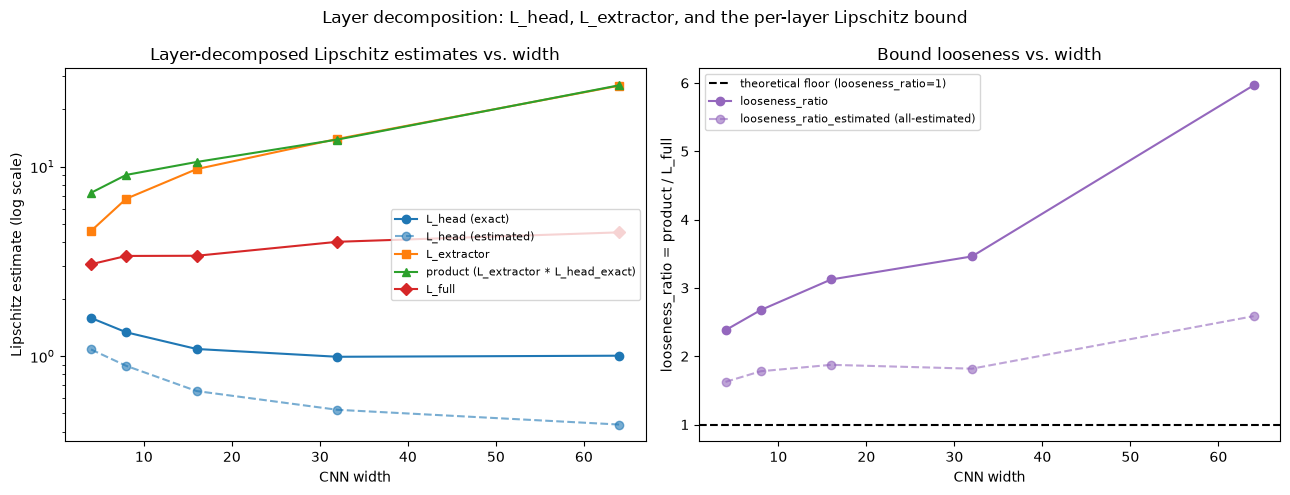

In [7]:
fig_sweep = plots.plot_layer_decomposition_sweep(
    sweep_df, save_path=layer_decomposition.RESULTS_DIR / "layer_decomposition_width_sweep.png")

## Summary and status

See the printed tables and plot above for the actual measured numbers
(they vary run to run with the random seed and aren't restated here to
avoid this notebook silently going stale against its own output -- re-run
the cells above for the current numbers).

**Design decisions worth flagging**:
- `L_full` here is the full logit vector's Lipschitz constant, not the
  scalar margin used elsewhere in this project -- see the Motivation
  section above and `layer_decomposition.py`'s module docstring for why
  that's the mathematically correct comparison for this specific bound.
- `L_head_exact` is recomputed against the *effective* (standardization-
  adjusted) head weights when `normalize_features=True`, not the raw
  weights unconditionally -- otherwise it would silently compare against
  the wrong input scale. See `_effective_head_lipschitz_exact`'s
  docstring.
- The `"grid"` (finite-difference) method converges much more slowly than
  `"pairwise"` or `"gradient"` when applied to the head, because its
  random perturbation directions live in the extractor's 1568-d feature
  space -- the same curse-of-dimensionality effect `toy_lipschitz` found
  for its own local-perturbation estimator. This is expected, not a bug
  (see `tests/test_layer_decomposition.py`).
- The CNN-width sweep is new, self-contained infrastructure (no existing
  capacity sweep existed in `mnist_lipschitz` to extend, unlike
  `toy_lipschitz`'s MLP sweep) -- trains on a dev subset for speed, not
  the full 60k training set.

This is a sub-experiment within Experiment 2 (`mnist_lipschitz`). See
`README.md` in this folder for the project-level write-up; this notebook
and `layer_decomposition.py` are additive to it, not a replacement for
anything in `notebook_mnist_lipschitz.ipynb`.